
ENTANGLEMENT-BASED QKD SIMULATION

Bell-state based communication model
---------------------------------------------------------------------------
Alice and Bob share entangled Phi+ pairs.
Both randomly choose measurement bases.
Only matching-basis measurements are retained.
The retained results form a shared key.

BASIS STATISTICS
---------------------------------------------------------------------------
Z-Z rounds : 254
X-X rounds : 257
Z-X rounds : 247
X-Z rounds : 266

KEY GENERATION
---------------------------------------------------------------------------
Matching-basis rounds : 511
Discarded rounds      : 513
Alice-Bob mismatches  : 0
Key agreement         : 100.00%

SAMPLE SHARED KEY
---------------------------------------------------------------------------
Alice : 11000110110011011111000100100000
Bob   : 11000110110011011111000100100000

QKD INTERPRETATION
---------------------------------------------------------------------------
Matching measurement bases produce correl

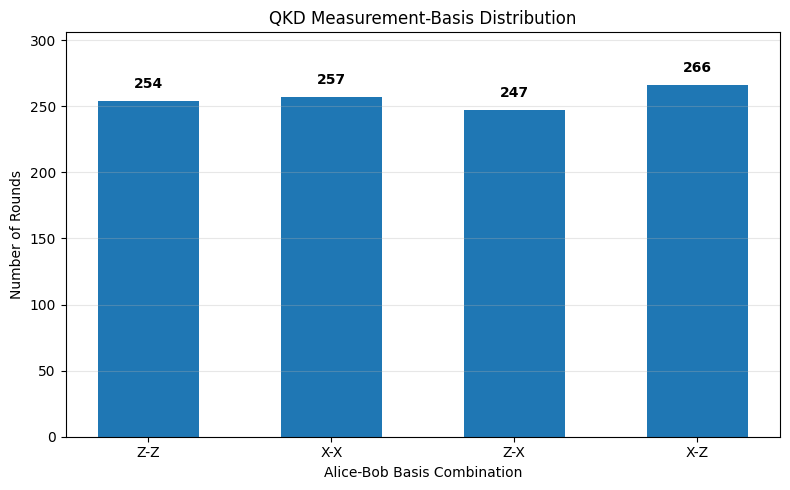

In [1]:
import numpy as np
import matplotlib.pyplot as plt

SHOTS = 1024
SEED = 42

rng = np.random.default_rng(SEED)

print("\nENTANGLEMENT-BASED QKD SIMULATION")
print("=" * 75)

print("\nBell-state based communication model")
print("-" * 75)

print("Alice and Bob share entangled Phi+ pairs.")
print("Both randomly choose measurement bases.")
print("Only matching-basis measurements are retained.")
print("The retained results form a shared key.")

alice_bases = rng.choice(
    ["Z", "X"],
    size=SHOTS
)

bob_bases = rng.choice(
    ["Z", "X"],
    size=SHOTS
)

alice_bits = []
bob_bits = []
matching_rounds = []

for i in range(SHOTS):

    if alice_bases[i] == bob_bases[i]:

        bit = rng.integers(0, 2)

        alice_bits.append(bit)
        bob_bits.append(bit)

        matching_rounds.append(i)

print("\nBASIS STATISTICS")
print("-" * 75)

z_z = np.sum(
    (alice_bases == "Z")
    & (bob_bases == "Z")
)

x_x = np.sum(
    (alice_bases == "X")
    & (bob_bases == "X")
)

z_x = np.sum(
    (alice_bases == "Z")
    & (bob_bases == "X")
)

x_z = np.sum(
    (alice_bases == "X")
    & (bob_bases == "Z")
)

print(f"Z-Z rounds : {z_z}")
print(f"X-X rounds : {x_x}")
print(f"Z-X rounds : {z_x}")
print(f"X-Z rounds : {x_z}")

print("\nKEY GENERATION")
print("-" * 75)

print(
    f"Matching-basis rounds : "
    f"{len(matching_rounds)}"
)

print(
    f"Discarded rounds      : "
    f"{SHOTS - len(matching_rounds)}"
)

alice_key = np.array(
    alice_bits
)

bob_key = np.array(
    bob_bits
)

if len(alice_key) > 0:

    mismatches = np.sum(
        alice_key != bob_key
    )

    agreement = (
        1
        - mismatches / len(alice_key)
    ) * 100

else:

    mismatches = 0
    agreement = 0

print(
    f"Alice-Bob mismatches  : "
    f"{mismatches}"
)

print(
    f"Key agreement         : "
    f"{agreement:.2f}%"
)

print("\nSAMPLE SHARED KEY")
print("-" * 75)

print(
    "Alice :",
    "".join(
        map(
            str,
            alice_key[:32]
        )
    )
)

print(
    "Bob   :",
    "".join(
        map(
            str,
            bob_key[:32]
        )
    )
)

print("\nQKD INTERPRETATION")
print("-" * 75)

print(
    "Matching measurement bases produce "
    "correlated key bits."
)

print(
    "Non-matching basis rounds are discarded."
)

print(
    "An eavesdropper disturbing the quantum states "
    "can introduce detectable errors."
)

print(
    "\nRESULT : Entanglement provides correlated "
    "measurement outcomes that can be used for "
    "shared-key generation."
)

fig, ax = plt.subplots(
    figsize=(8, 5)
)

basis_labels = [
    "Z-Z",
    "X-X",
    "Z-X",
    "X-Z"
]

basis_values = [
    z_z,
    x_x,
    z_x,
    x_z
]

bars = ax.bar(
    basis_labels,
    basis_values,
    width=0.55
)

ax.set_title(
    "QKD Measurement-Basis Distribution"
)

ax.set_xlabel(
    "Alice-Bob Basis Combination"
)

ax.set_ylabel(
    "Number of Rounds"
)

ax.set_ylim(
    0,
    max(basis_values) * 1.15
)

for bar, value in zip(
    bars,
    basis_values
):

    ax.text(
        bar.get_x()
        + bar.get_width() / 2,
        value + 10,
        str(value),
        ha="center",
        fontweight="bold"
    )

ax.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()